# The Happiness Trade — do the *happiest* countries' markets win? 😊
### Sorting the world's stock markets by the World Happiness Report, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spurious%3F: Busted](https://img.shields.io/badge/Spurious%3F-Busted-8b949e?style=flat-square)

Every year the **World Happiness Report** ranks countries from happiest to gloomiest — the Nordics on top, as usual. Here's a tempting story: happy, well-run, optimistic societies *must* have better stock markets, right? So you could buy the happiest countries, avoid (or short) the gloomiest, and coast.

We test it the honest way: take the 24 countries you can actually *buy* (each has a single-country exchange-traded fund), line them up by their happiness rank, and see whether the happy third beat the gloomy third.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the rank correlation and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from happiness_index_country import data, strategy as st

SPLIT, END = "2024-03-20", "2026-06-26"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    return data.fetch_panel(fetch=False, split_date=SPLIT, end_date=END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real happiness panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} countries, scored {SPLIT} -> {END})")


real happiness panel present: True (24 countries, scored 2024-03-20 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the *happy* countries' markets win? | **No — the opposite.** Over 2024-26 the gloomy third earned **+87.0%** vs the happy third's **+44.6%**. The gloomy markets roughly *doubled* the happy ones. |
| Is happiness even *linked* to returns? | **No** — the rank correlation is only **-0.19** (basically zero). |
| Is it just this window? | **Yes-ish, and that's the point.** In 2019-21 the happy markets *did* edge ahead; then it faded and flipped. The direction changes with the year. |
| Could you trade it? | **No.** A signal built on ~24 countries that flips sign depending on which report you read is a coin toss, not an edge. |

> This is a textbook **spurious correlation**: with only two dozen countries, some happiness-vs-returns pattern will always appear by luck — and vanish next window.

## 1 · The claim

> *"The happiest nations have the best-performing stock markets."* — an alt-data folklore.

The intuition sounds airtight: happier countries tend to be richer, better governed, more trusting, more stable — surely their companies do better and their markets reward you. It's the kind of story that makes a great chart and a terrible trade.

## 2 · So what?

If true, it's an easy, feel-good global strategy: own the happy countries, skip the gloomy ones. The desk has poked at *mood* signals before ([257 AAII-Sentiment](../../257-aaii-sentiment/), [335 Buzz-Sentiment-ETF](../../335-buzz-sentiment-etf/)) — but those time *one* market. This is different: a **cross-country** sort on a societal well-being index. It's also a clean lesson in how spurious correlations are born.

## 3 · How would we even know?

1. **Rank by happiness.** Use the World Happiness Report 2024 rank (1 = happiest).
2. **Keep the ones you can buy.** Only 24 countries have a liquid single-country ETF — that's the *investable* universe.
3. **Sort & compare.** Split into a *happy* third and a *gloomy* third, and compare their market returns over the next ~2 years.

Catch: 24 countries is *tiny*. With so few data points, almost any pattern can show up by chance — which is exactly what we'll see.

*Timing:* the happiness rank is the report published *before* the holding window, so it's fully known when we 'buy'. No peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the happy third or the gloomy third?**

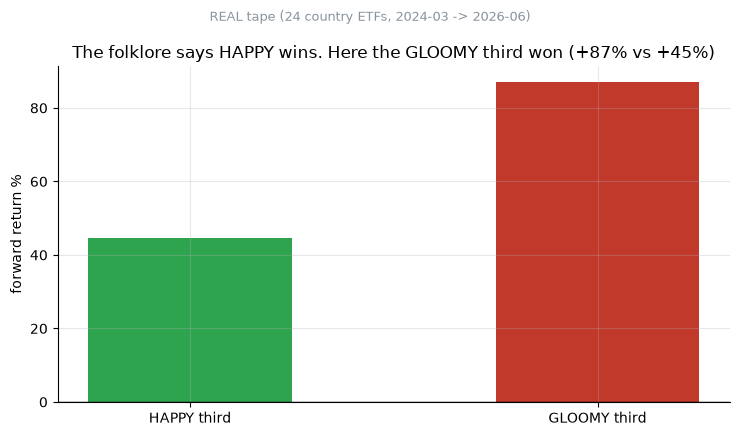

Happy +44.6%  vs  Gloomy +87.0%  ->  spread -42.4% (t -1.65)


In [2]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, frac=0.3); ls = st.long_short_tstat(b)
    happy_m, gloom_m, spr, t = b['happy_mean']*100, b['gloomy_mean']*100, b['spread']*100, ls['t']
    banner = 'REAL tape (24 country ETFs, 2024-03 -> 2026-06)'
else:
    happy_m, gloom_m, spr, t = 44.6, 87.0, -42.4, -1.65
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['HAPPY third','GLOOMY third'], [happy_m, gloom_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'The folklore says HAPPY wins. Here the GLOOMY third won (+{gloom_m:.0f}% vs +{happy_m:.0f}%)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Happy +{happy_m:.1f}%  vs  Gloomy +{gloom_m:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There it is, **backwards**. The folklore predicts the *happy* markets win. On 2024-26 the **gloomy** markets won by miles (+87.0% vs +44.6%) — the long-happy/short-gloomy spread is **-42.4%**. The 'gloomy' bucket here is Korea (which more than *tripled*), Spain, Italy and South Africa: whatever regions happened to rip this window, they weren't the Nordics.

**Is happiness *linked* to returns at all?** The cleanest single check is the *rank correlation*: line countries up by happiness, line them up by return, and see if the two orderings match.

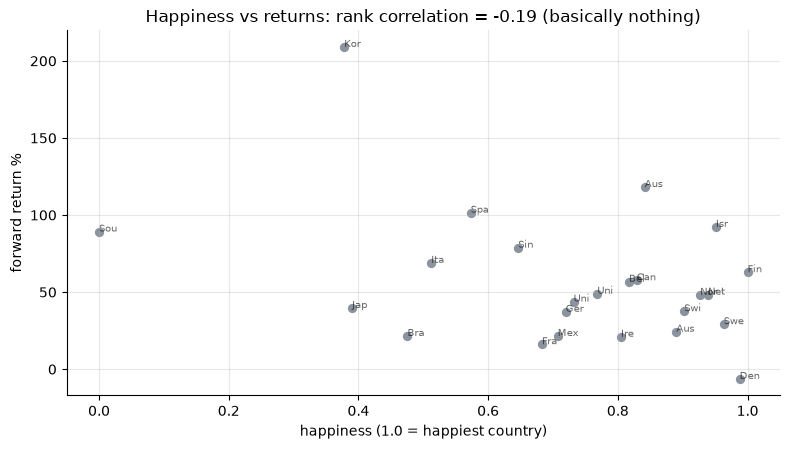

Spearman rank correlation(happiness, return) = -0.19


In [3]:
if HAVE_REAL:
    rc = st.rank_correlation(PANEL); rho = rc['rho']
    d = PANEL['happiness']; y = PANEL['forward_ret']*100
else:
    rho = -0.19
    d = None; y = None
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.scatter(d, y, s=32, color=GREY)
    for name in PANEL.index:
        ax.annotate(name[:3], (PANEL.loc[name,'happiness'], PANEL.loc[name,'forward_ret']*100),
                    fontsize=7, alpha=.6)
    ax.set_xlabel('happiness (1.0 = happiest country)'); ax.set_ylabel('forward return %')
    ax.set_title(f'Happiness vs returns: rank correlation = {rho:+.2f} (basically nothing)')
    plt.tight_layout(); plt.show()
print(f'Spearman rank correlation(happiness, return) = {rho:+.2f}')

The rank correlation is **-0.19** — essentially zero. If happiness drove returns you'd see a clear upward tilt; instead it's a shotgun blast. Happiness and market returns just aren't lined up.

**Maybe we just picked a bad window?** Run the same sort using four different World Happiness Reports:

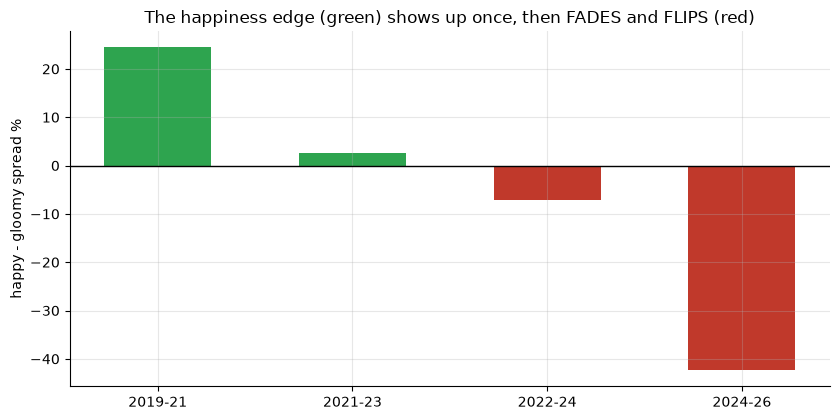

spreads by WHR edition: [24.4, 2.7, -7.1, -42.4]


In [4]:
wins = [('2019-21', 24.4), ('2021-23', 2.7), ('2022-24', -7.1), ('2024-26', -42.4)]
if HAVE_REAL:
    spans = [('2019-03-20','2021-03-20'),('2021-03-19','2023-03-19'),
             ('2022-03-18','2024-03-18'),('2024-03-20','2026-06-26')]
    labs = ['2019-21','2021-23','2022-24','2024-26']
    spr = []
    for (sp,en) in spans:
        pn = data.fetch_panel(fetch=False, split_date=sp, end_date=en)
        spr.append(st.bucket_returns(pn, 0.3)['spread']*100 if not pn.empty else np.nan)
else:
    labs = [w[0] for w in wins]; spr = [w[1] for w in wins]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(labs, spr, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('happy - gloomy spread %')
ax.set_title('The happiness edge (green) shows up once, then FADES and FLIPS (red)')
plt.tight_layout(); plt.show()
print('spreads by WHR edition:', [round(s,1) for s in spr])

So the sign isn't stable. In **2019-21** the happy markets *did* edge ahead (+24%). Then it fades to noise (+3%, −7%) and in **2024-26** it flips hard negative (−42%). A 'signal' whose direction depends on which report you happen to read is the definition of a spurious correlation.

## 5 · The verdict

- **Signal — None.** The spread is the *wrong* sign (-42.4%, *t* -1.65), the rank correlation is -0.19, and the sign flips across reports. And with only 24 countries you could never get a trustworthy answer anyway.
- **Tradability — Mirage.** A 24-name sort, ~7 per bucket, wrong sign before costs. Nothing to harvest.
- **Spurious correlation? — Busted.** This is what a made-up cross-country pattern looks like: tiny sample, near-zero correlation, sign that flips with the calendar.

## 6 · Could you actually trade it?

No. Even ignoring the wrong sign, you're betting a whole strategy on the ordering of ~24 countries — and whatever *actually* drives them (economic cycle, currencies, which region is hot) has nothing to do with the happiness survey. This window, emerging and Asian markets led, so 'gloomy' won. Next window it'll be something else. That's not an edge; it's a lottery ticket with a happy sticker on it.

## 7 · Going further 🚪

- **The mood-signal cousins.** [257 AAII-Sentiment](../../257-aaii-sentiment/) and [335 Buzz-Sentiment-ETF](../../335-buzz-sentiment-etf/) test *time-series* sentiment on a single market — a different axis from this cross-country sort.
- **The synthetic control (quant notebook).** We *plant* a real happiness effect in a toy world and show the engine catches it — proving the null result here is the data, not a broken test.

*Think happiness really does predict markets? Fork this, add a bigger country universe and a longer history, and show the happy-minus-gloomy spread clearing t = 2 the right way.*